In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('Hospital.csv')

In [3]:
df.head()

,Patient_ID,Date,Hour,Department,Patient_Type,Emergency_Cases,Patient_Arrivals,Queue_Length,Available_Doctors,Available_Nurses,Hospital_Capacity,Occupied_Beds,Discharge_Count,Crowding_Level
0,P_100000,2026-04-15,14,Outpatient,Follow-up,1,38,0,13,39,200,158,8,Medium
1,P_100001,2025-10-12,11,Outpatient,Follow-up,12,81,9,12,36,200,149,10,Medium
2,P_100002,2025-08-02,16,Outpatient,Routine,4,29,13,4,8,200,107,20,High
3,P_100003,2025-11-04,23,Pediatrics,Routine,0,8,0,5,20,60,44,7,Low
4,P_100004,2026-05-31,20,Emergency,Urgent,31,67,0,15,30,80,49,7,Low


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Patient_ID         50000 non-null  str  
 1   Date               50000 non-null  str  
 2   Hour               50000 non-null  int64
 3   Department         50000 non-null  str  
 4   Patient_Type       50000 non-null  str  
 5   Emergency_Cases    50000 non-null  int64
 6   Patient_Arrivals   50000 non-null  int64
 7   Queue_Length       50000 non-null  int64
 8   Available_Doctors  50000 non-null  int64
 9   Available_Nurses   50000 non-null  int64
 10  Hospital_Capacity  50000 non-null  int64
 11  Occupied_Beds      50000 non-null  int64
 12  Discharge_Count    50000 non-null  int64
 13  Crowding_Level     50000 non-null  str  
dtypes: int64(9), str(5)
memory usage: 7.2 MB


In [5]:
df.describe()

,Hour,Emergency_Cases,Patient_Arrivals,Queue_Length,Available_Doctors,Available_Nurses,Hospital_Capacity,Occupied_Beds,Discharge_Count
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,11.505540,9.683860,38.194140,11.289180,7.110740,21.333520,124.850800,78.668460,11.289580
std,6.939102,14.472272,26.579435,15.679921,4.452342,14.999723,62.341507,46.449286,8.733909
min,0.000000,0.000000,5.000000,0.000000,2.000000,4.000000,50.000000,15.000000,0.000000
25%,5.000000,1.000000,17.000000,0.000000,4.000000,10.000000,80.000000,42.000000,5.000000
50%,11.000000,4.000000,30.000000,4.000000,6.000000,16.000000,100.000000,64.000000,9.000000
75%,18.000000,12.000000,57.000000,17.000000,10.000000,28.000000,200.000000,116.000000,15.000000
max,23.000000,88.000000,99.000000,81.000000,17.000000,68.000000,200.000000,195.000000,48.000000


In [6]:
df.shape

(50000, 14)

In [7]:
df_processed = df.drop(columns=['Patient_ID'])

#Extacting months & day Of week from date coulmn and add them
df_processed['Date'] = pd.to_datetime(df_processed['Date'])
df_processed['Month'] = df_processed['Date'].dt.month
df_processed['DayOfWeek'] = df_processed['Date'].dt.dayofweek
df_processed = df_processed.drop(columns=['Date'])

In [8]:
df_processed.head()

,Hour,Department,Patient_Type,Emergency_Cases,Patient_Arrivals,Queue_Length,Available_Doctors,Available_Nurses,Hospital_Capacity,Occupied_Beds,Discharge_Count,Crowding_Level,Month,DayOfWeek
0,14,Outpatient,Follow-up,1,38,0,13,39,200,158,8,Medium,4,2
1,11,Outpatient,Follow-up,12,81,9,12,36,200,149,10,Medium,10,6
2,16,Outpatient,Routine,4,29,13,4,8,200,107,20,High,8,5
3,23,Pediatrics,Routine,0,8,0,5,20,60,44,7,Low,11,1
4,20,Emergency,Urgent,31,67,0,15,30,80,49,7,Low,5,6


#### Feature Engineering

In [9]:
# Create Bed Occupancy Rate feature: measures current hospital saturation level
df_processed['Bed_Occupancy_Rate'] = df_processed['Occupied_Beds'] / df_processed['Hospital_Capacity']
# Calculate Total Available Staff: combines active doctors and nurses
df_processed['Total_Staff'] = df_processed['Available_Doctors'] + df_processed['Available_Nurses']
# Compute Staff to Patient Ratio: assesses medical workload per arriving patient (+1 to prevent division by zero)
df_processed['Staff_to_Patient_Ratio'] = df_processed['Total_Staff'] / (df_processed['Patient_Arrivals'])

In [10]:
#One-Hot Encoding
df_processed = pd.get_dummies(df_processed, columns=['Department', 'Patient_Type'], drop_first=True)

In [11]:
#Target Encoding
target_mapping = {'Low': 0, 'Medium': 1, 'High': 2}
df_processed['Crowding_Level'] = df_processed['Crowding_Level'].map(target_mapping)

In [12]:
print("Shape after preprocessing:", df_processed.shape)
df_processed.head()

Shape after preprocessing: (50000, 21)


,Hour,Emergency_Cases,Patient_Arrivals,Queue_Length,Available_Doctors,Available_Nurses,Hospital_Capacity,Occupied_Beds,Discharge_Count,Crowding_Level,...,DayOfWeek,Bed_Occupancy_Rate,Total_Staff,Staff_to_Patient_Ratio,Department_Internal Medicine,Department_Outpatient,Department_Pediatrics,Department_Surgery,Patient_Type_Routine,Patient_Type_Urgent
0,14,1,38,0,13,39,200,158,8,1,...,2,0.790000,52,1.368421,False,True,False,False,False,False
1,11,12,81,9,12,36,200,149,10,1,...,6,0.745000,48,0.592593,False,True,False,False,False,False
2,16,4,29,13,4,8,200,107,20,2,...,5,0.535000,12,0.413793,False,True,False,False,True,False
3,23,0,8,0,5,20,60,44,7,0,...,1,0.733333,25,3.125000,False,False,True,False,True,False
4,20,31,67,0,15,30,80,49,7,0,...,6,0.612500,45,0.671642,False,False,False,False,False,True


In [13]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df_processed.drop(columns=['Crowding_Level'])
y = df_processed['Crowding_Level']


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [14]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

X_train shape: (40000, 20)
X_test shape: (10000, 20)


In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, f1_score
import pandas as pd

In [16]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42)
}

In [17]:
results = []
for name, model in models.items():
    if name == 'Logistic Regression':
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    results.append({'Model': name, 'Accuracy': round(acc, 4), 'F1-Score': round(f1, 4)})

In [19]:
results_df = pd.DataFrame(results)
print(results_df)

                 Model  Accuracy  F1-Score
0  Logistic Regression    0.9657    0.9655
1        Decision Tree    0.9917    0.9917
2        Random Forest    0.9848    0.9848
3    Gradient Boosting    0.9888    0.9888


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

best_model = DecisionTreeClassifier(random_state=42)
best_model.fit(X_train, y_train)
y_pred_best = best_model.predict(X_test)

In [21]:
print("--- Classification Report ---")
print(classification_report(y_test, y_pred_best, target_names=['Low', 'Medium', 'High']))

--- Classification Report ---
              precision    recall  f1-score   support

         Low       1.00      1.00      1.00      3544
      Medium       0.98      0.97      0.98      1842
        High       0.99      0.99      0.99      4614

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



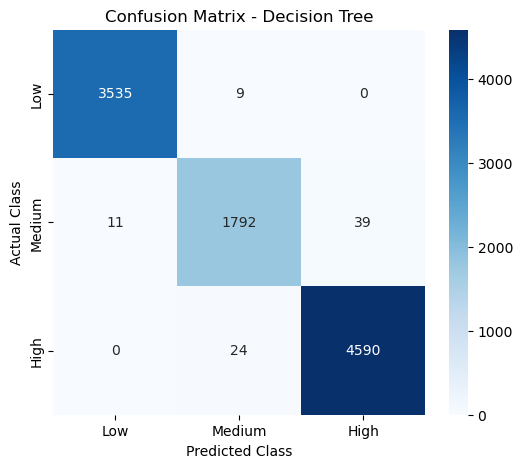

In [22]:
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Low', 'Medium', 'High'], 
            yticklabels=['Low', 'Medium', 'High'])
plt.title('Confusion Matrix - Decision Tree')
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.show()

C:\Users\Z\AppData\Local\Temp\ipykernel_25572\3327352289.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_imp.head(10), y=feature_imp.head(10).index, palette='viridis')


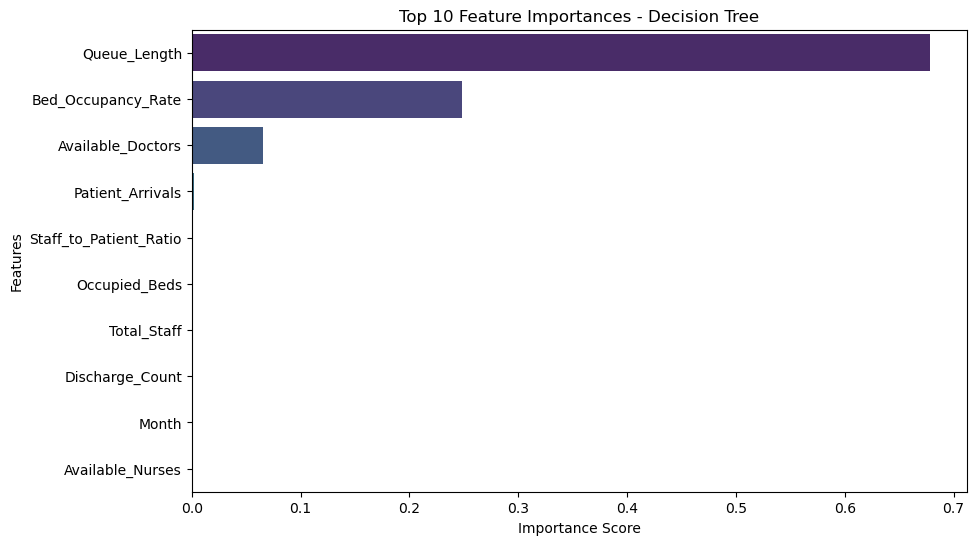

In [25]:
importances = best_model.feature_importances_
feature_names = X.columns
feature_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=feature_imp.head(10), y=feature_imp.head(10).index, palette='viridis')
plt.title('Top 10 Feature Importances - Decision Tree')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.show()

In [26]:
print("Top Features Importance:")
print(feature_imp.head(10))

Top Features Importance:
Queue_Length              0.678225
Bed_Occupancy_Rate        0.248553
Available_Doctors         0.065258
Patient_Arrivals          0.002320
Staff_to_Patient_Ratio    0.001182
Occupied_Beds             0.000958
Total_Staff               0.000811
Discharge_Count           0.000584
Month                     0.000537
Available_Nurses          0.000428
dtype: float64


In [27]:
import joblib

joblib.dump(best_model, 'hospital_crowding_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

print("Model and Scaler saved successfully!")

Model and Scaler saved successfully!


## Executive Summary & Business Insights

### 1. Model Performance:
- The **Decision Tree Classifier** achieved the highest accuracy (**99.17%**) and F1-Score (**0.9917**) in predicting hospital crowding levels.
- Confusion Matrix proves minimal misclassifications between adjacent crowding levels (Low, Medium, High).

### 2. Key Findings:
- **Queue Length** is the primary indicator for hospital congestion, accounting for over 65% of prediction weight.
- Operational capacity features, especially the engineered **Bed Occupancy Rate** (~25%), play a vital secondary role.
- Medical workforce availability (`Available_Doctors`) acts as a critical balance parameter.

### 3. Business Recommendations:
- Real-time monitoring of queue length should trigger immediate dynamic patient routing.
- Maintaining bed occupancy below critical thresholds prevents overall capacity bottlenecks.